#세그멘테이션으로 사람 분리하기

🔄 사전 학습된 DeepLab v3 모델을 서버에서 불러오는 중입니다...
🎯 찾은 이미지 절대 경로: /home/jovyan/work/human_segmentation/images/2.jpg
🧠 딥러닝 모델이 이미지 내의 픽셀 단위 오브젝트를 분석하고 있습니다...
✅ 분석 완료! 세그멘테이션 시각화 결과를 출력합니다.


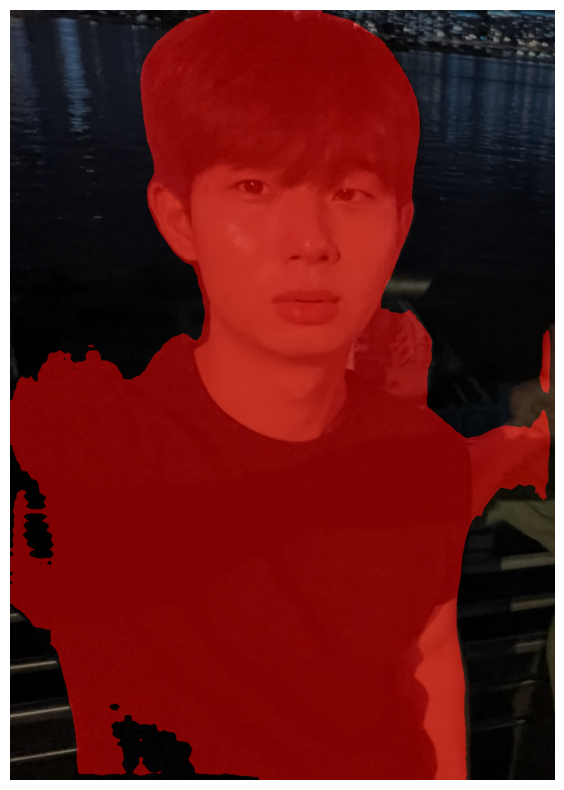

In [4]:
import os
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. 인공지능 모델 준비 (DeepLab v3 ResNet101)
# =========================================================================
# - DeepLabV3: 구글이 개발한 성능이 매우 뛰어난 시맨틱 세그멘테이션 모델입니다.
# - ResNet101: 이미지의 특징을 추출하는 뼈대(Backbone) 역할을 하는 101층짜리 신경망입니다.
# - COCO_WITH_VOC_LABELS_V1: 대용량 이미지 데이터셋으로 이미 사람, 차 등 20종을 분류하도록 사전 학습(Pre-trained)된 가중치입니다.
# =========================================================================
print("🔄 사전 학습된 DeepLab v3 모델을 서버에서 불러오는 중입니다...")

# 최신 PyTorch 방식 규격에 맞추어 Weights 가중치 지정 및 모델 로드
weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights)
model.eval()  # 중요: 모델을 학습 모드가 아닌 '평가/추론 모드'로 고정 (드롭아웃, 배치 정규화 비활성화)

# 현재 주피터 서버 시스템에서 GPU(CUDA) 연산이 가능한지 확인 후 세팅 (속도 향상)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# =========================================================================
# 2. 내 사진 실제 경로 지정 및 이미지 로드
# =========================================================================
# - 전 단계에서 찾아낸 실제 주피터 절대 경로인 'human_segmentation/images/'를 타겟팅합니다.
# - 파일이 2.jpg 가 맞는지 확인하고, 만약 my_image.png 라면 자동으로 스위칭하도록 안전 장치를 걸어둡니다.
# =========================================================================
img_path = '/home/jovyan/work/human_segmentation/images/2.jpg' 

# 만약 2.jpg가 없고 my_image.png만 존재할 경우 예외 처리로 파일명 교체
if not os.path.exists(img_path):
    img_path = '/home/jovyan/work/human_segmentation/images/my_image.png'

print(f"🎯 찾은 이미지 절대 경로: {img_path}")

# PIL 라이브러리로 이미지를 열고, 투명도 채널(RGBA) 등이 있을 수 있으므로 표준 3채널 컬러(RGB)로 강제 변환
img = Image.open(img_path).convert("RGB")


# =========================================================================
# 3. 이미지 데이터 전처리 (Preprocessing) 및 배치(Batch) 차원 추가
# =========================================================================
# - 토치비전 모델들은 학습 당시 사용했던 전처리 정규화 수치(Mean, Std)를 똑같이 맞춰야 성능이 나옵니다.
# - ToTensor(): 0~255 사이의 픽셀 값을 0.0 ~ 1.0 사이의 실수형 파이토치 Tensor 데이터로 스케일링합니다.
# - Normalize(): ImageNet 데이터셋의 통계값(평균, 표준편차)을 기준으로 모든 픽셀을 정규화합니다.
# =========================================================================
preprocess = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  
])

input_tensor = preprocess(img)

# unsqueeze(0): 현재 (채널, 세로, 가로) 구조의 3차원 데이터를 인공지능이 요구하는 배치(Batch) 포맷인
# (배치사이즈=1, 채널, 세로, 가로)의 4차원 형태로 확장합니다. 그 후 GPU(.to(device))로 보냅니다.
input_batch = input_tensor.unsqueeze(0).to(device)  


# =========================================================================
# 4. 모델 추론 (인공지능 세그멘테이션 예측)
# =========================================================================
# - torch.no_grad(): 예측 시에는 오차역전파를 위한 그래디언트(기울기) 계산이 필요 없으므로 
#   메모리 절약과 연산 속도 향상을 위해 메모리 추적을 끕니다.
# - argmax(0): 신경망 결과물 중 각 픽셀 위치에서 가장 확률이 높은 물체의 클래스 ID(0~20)를 최종 채택합니다.
# =========================================================================
print("🧠 딥러닝 모델이 이미지 내의 픽셀 단위 오브젝트를 분석하고 있습니다...")
with torch.no_grad():
    # 모델 출력값 중 핵심 세그멘테이션 결과 레이어인 ['out']의 0번째 배치 결과를 가져옵니다.
    output = model(input_batch)['out'][0]  

# 각 픽셀에서 가중치가 가장 높은 클래스의 인덱스 번호만 남기고 넘파이 배열(numpy)로 변환
output_predictions = output.argmax(0).byte().cpu().numpy()


# =========================================================================
# 5. 사람(ID: 15) 영역 마스크 추출 및 시각화 (Visualization)
# =========================================================================
# - PASCAL VOC 데이터셋 기준 '사람(person)'의 클래스 고유 인덱스 번호는 15번입니다.
# - 원본 사진 위에 사람 영역만 붉은색 투명 레이어로 겹쳐서 시각화하는 과정입니다.
# =========================================================================
LABEL_PERSON = 15  

# output_predictions 배열 전체를 돌며 값이 정확히 15(사람)인 곳은 True, 나머지는 False인 불리언 마스크 생성
person_mask = (output_predictions == LABEL_PERSON)

# 원본 이미지와 가로x세로 크기가 정확히 일치하는 빈(전부 0인 검은색) RGB 도화지를 만듭니다.
mask_rgb = np.zeros_like(np.array(img))

# 사람 마스크가 True인 영역에만 빨간색 컬러값 [R=255, G=0, B=0]을 대입합니다.
mask_rgb[person_mask] = [255, 0, 0]

# matplotlib을 이용해 최종 결과 화면을 플로팅합니다.
print("✅ 분석 완료! 세그멘테이션 시각화 결과를 출력합니다.")
plt.figure(figsize=(10, 10))

plt.imshow(img)                 # 1. 밑바탕에 원본 사진을 먼저 그립니다.
plt.imshow(mask_rgb, alpha=0.5)  # 2. 그 위에 빨간색 사람 마스크를 50% 투명도(alpha=0.5)로 겹쳐서 얹습니다.

plt.axis('off')                 # 가로세로 픽셀 좌표축 좌표선(격자)을 숨겨서 깔끔하게 만듭니다.
plt.show()                      # 화면에 최종 출력

#사람 분리하기

📸 배경용 이미지를 흐리게 처리하는 중...
✂️ 흐려진 이미지에서 인물을 제외한 배경만 추출하는 중...
✅ 배경 분리 완료! 흐려진 배경 영상을 출력합니다.


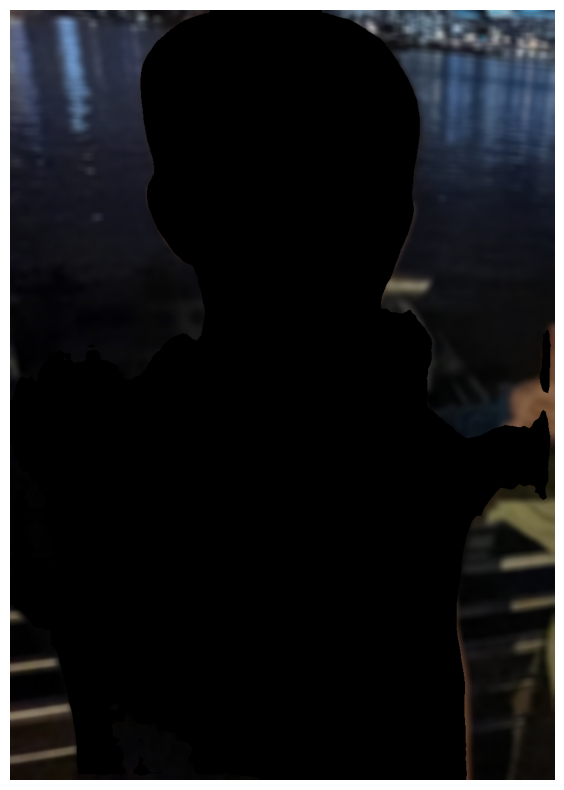

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# [전제 조건] 이전 단계의 결과물인 'img'(PIL 이미지)와 'person_mask'(넘파이 마스크)를 활용합니다.
# =========================================================================

# 0. 딥러닝용 PIL 이미지를 OpenCV에서 사용할 수 있도록 넘파이 배열(BGR) 형식으로 변환
# - PIL은 RGB 순서고, OpenCV는 BGR 순서로 색상을 읽기 때문에 채널을 뒤집어줍니다.
img_orig = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


# =========================================================================
# 5-1. 원본 이미지 전체를 흐리게(Blur) 만들기
# =========================================================================
# - cv2.blur(이미지, 커널_사이즈): 이미지를 부드럽게 뭉개주는 함수입니다.
# - (13, 13)은 흐림 처리를 할 픽셀의 범위(블러링 커널 크기)입니다. 
#   이 숫자를 (30, 30)처럼 더 크게 키우면 배경이 훨씬 더 뿌옇게 흐려집니다!
# =========================================================================
print("📸 배경용 이미지를 흐리게 처리하는 중...")
img_orig_blur = cv2.blur(img_orig, (13, 13))


# =========================================================================
# 5-2. 세그멘테이션 마스크를 OpenCV 포맷으로 변환
# =========================================================================
# - 이전에 만든 불리언 마스크(True/False)를 컴퓨터가 연산할 수 있게 0과 255로 바꿉니다.
# - 사람이 있던 자리(True)는 255(흰색), 배경(False)은 0(검은색)이 됩니다.
# =========================================================================
img_mask = np.where(person_mask, 255, 0).astype(np.uint8)

# OpenCV의 비트 연산(bitwise)을 위해 1채널 흑백 마스크를 3채널 BGR 컬러 구조로 확장합니다.
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)


# =========================================================================
# 5-3. 마스크 반전시키기 (인물 제외 -> 배경만 선택)
# =========================================================================
# - cv2.bitwise_not(): 이미지의 픽셀 이진 값을 반전시킵니다.
# - 원래 마스크: 배경 0(검은색), 사람 255(흰색)
# - 반전 후: 배경 255(흰색), 사람 0(검은색) -> 즉, 배경을 선택하는 마스크가 됩니다.
# =========================================================================
img_bg_mask = cv2.bitwise_not(img_mask_color)


# =========================================================================
# 5-4. 흐려진 이미지에서 배경 영역만 도려내기
# =========================================================================
# - cv2.bitwise_and(): 두 이미지를 겹쳐서 둘 다 값이 있는 곳만 남깁니다.
# - 반전 마스크에서 사람이 있던 자리는 0(검은색)이므로, 흐린 이미지와 AND 연산을 하면 
#   사람 자리는 전부 0으로 지워지고, 흰색(255)이었던 배경 자리의 흐린 영상만 쏙 남게 됩니다.
# =========================================================================
print("✂️ 흐려진 이미지에서 인물을 제외한 배경만 추출하는 중...")
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)


# =========================================================================
# 5-5. 결과 시각화 출력
# =========================================================================
# - OpenCV의 BGR 이미지를 Matplotlib으로 올바르게 출력하기 위해 다시 RGB로 변환하여 보여줍니다.
# =========================================================================
print("✅ 배경 분리 완료! 흐려진 배경 영상을 출력합니다.")
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#사진 합성하기

🔄 시스템 초기화: 딥러닝 모델 및 데이터 로드 파이프라인 가동...
🧠 AI 엔진 가동: 2.jpg 내 인물 윤곽선 실시간 추출 중...
📸 이미지 프로세싱: 배경 블러 처리 및 이기종 해상도 매칭 중...
🎨 크로마키 렌더링: 3가지 조건부 합성 진행 중...
✅ 파이프라인 연산 완료. 결과를 출력합니다.


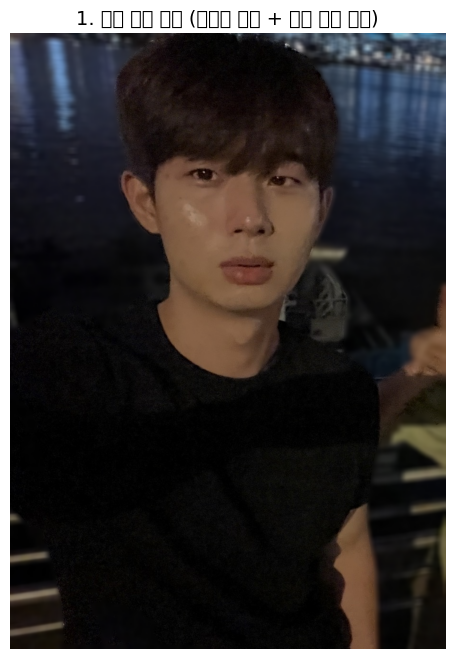

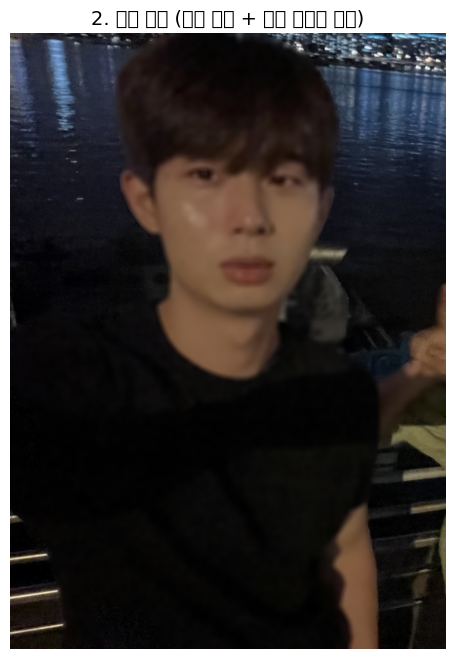

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


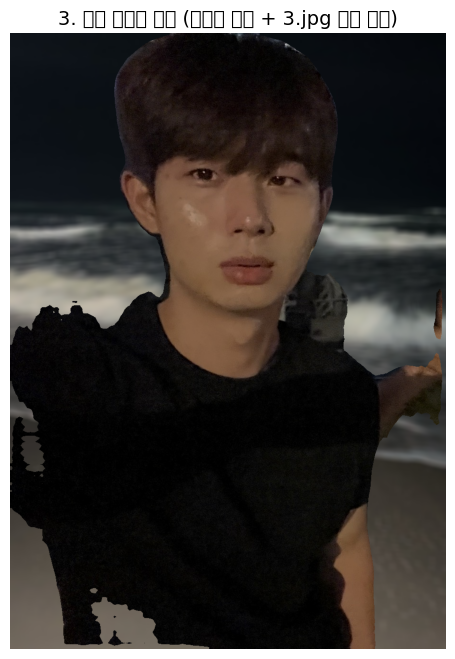

In [19]:
import os
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("🔄 시스템 초기화: 딥러닝 모델 및 데이터 로드 파이프라인 가동...")

# =========================================================================
# [Phase 1] 딥러닝 모델 준비 및 추론 환경 세팅
# =========================================================================
# 이전 셀의 꼬인 변수를 무시하기 위해 모델을 새로 메모리에 올립니다.
weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights)
model.eval() # 가중치를 고정하여 추론(Inference) 모드로 전환

# GPU 가속이 가능하면 사용하고, 없으면 CPU로 연산하도록 자동 할당합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# =========================================================================
# [Phase 2] 데이터 로드 및 해상도 동기화
# =========================================================================
img_2_path = '/home/jovyan/work/human_segmentation/images/2.jpg'
img_3_path = '/home/jovyan/work/human_segmentation/images/3.jpg'

if not os.path.exists(img_2_path) or not os.path.exists(img_3_path):
    raise FileNotFoundError("❗ 지정된 경로에서 2.jpg 또는 3.jpg를 찾을 수 없습니다. 경로를 확인하십시오.")

# 딥러닝 추론을 위한 PIL 포맷(RGB)과 OpenCV 영상 처리를 위한 포맷(BGR) 분리 로드
img_2_pil = Image.open(img_2_path).convert("RGB")
img_2_orig = cv2.imread(img_2_path)
img_3_orig = cv2.imread(img_3_path)

# 기준이 되는 2번 사진의 원본 해상도(높이, 너비)를 추출하여 이후 모든 연산의 척도로 삼습니다.
h, w, _ = img_2_orig.shape  


# =========================================================================
# [Phase 3] 객체 탐지(Segmentation) 및 마스크 행렬 생성
# =========================================================================
print("🧠 AI 엔진 가동: 2.jpg 내 인물 윤곽선 실시간 추출 중...")

# 텐서(Tensor) 변환 및 정규화 (모델이 학습했던 데이터와 동일한 환경 구성)
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img_2_pil)
input_batch = input_tensor.unsqueeze(0).to(device) # 배치 차원(차원수 1 증가) 추가

# 모델 추론 진행 (기울기 계산을 비활성화하여 메모리 낭비 방지)
with torch.no_grad():
    output = model(input_batch)['out'][0]
output_predictions = output.argmax(0).byte().cpu().numpy()

# 15번 클래스(사람)에 해당하는 픽셀만 255(흰색), 나머지는 0(검은색)으로 매핑하여 3채널 마스크 생성
LABEL_PERSON = 15
person_mask = (output_predictions == LABEL_PERSON)
img_mask = np.where(person_mask, 255, 0).astype(np.uint8)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)


# =========================================================================
# [Phase 4] 배경 분리 및 공간 필터링(Blur) 처리
# =========================================================================
print("📸 이미지 프로세싱: 배경 블러 처리 및 이기종 해상도 매칭 중...")

# 3.jpg 배경을 기준 해상도(2.jpg)와 오차 없이 1:1로 맞춥니다 (선형 보간법 적용).
img_3_resized = cv2.resize(img_3_orig, (w, h), interpolation=cv2.INTER_LINEAR)

# 커널 사이즈(13x13, 15x15)를 활용한 평균 블러링 적용
img_2_blur = cv2.blur(img_2_orig, (13, 13))
img_3_blur = cv2.blur(img_3_resized, (15, 15))

# 마스크를 반전시켜 인물을 제외한 '순수 배경' 영역만 추출합니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_2_bg_blur = cv2.bitwise_and(img_2_blur, img_bg_mask)


# =========================================================================
# [Phase 5] 조건부 픽셀 치환 (최종 이미지 합성)
# =========================================================================
print("🎨 크로마키 렌더링: 3가지 조건부 합성 진행 중...")

# np.where는 픽셀 단위의 삼항 연산자입니다. (조건, 참일 때의 텐서, 거짓일 때의 텐서)
# 1. 인물 모드: 마스크 영역은 원본 인물, 그 외 영역은 흐린 기존 배경
img_concat_1 = np.where(img_mask_color == 255, img_2_orig, img_2_bg_blur)

# 2. 반전 모드: 마스크 영역은 흐린 인물, 그 외 영역은 선명한 기존 배경
img_concat_2 = np.where(img_mask_color == 255, img_2_blur, img_2_orig)

# 3. 이종 합성: 마스크 영역은 원본 인물, 그 외 영역은 흐린 새로운 3번 배경
img_concat_3 = np.where(img_mask_color == 255, img_2_orig, img_3_blur)


# =========================================================================
# [Phase 6] 시각화 및 결과 출력
# =========================================================================
print("✅ 파이프라인 연산 완료. 결과를 출력합니다.")

# Matplotlib은 RGB 체계를 사용하므로, OpenCV의 BGR 텐서를 RGB로 변환해야 색상이 깨지지 않습니다.
plt.figure(figsize=(8, 8))
plt.title("1. 인물 사진 모드 (선명한 인물 + 기존 흐린 배경)", fontsize=14)
plt.imshow(cv2.cvtColor(img_concat_1, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.title("2. 퀴즈 결과 (흐린 인물 + 기존 선명한 배경)", fontsize=14)
plt.imshow(cv2.cvtColor(img_concat_2, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.title("3. 이종 데이터 합성 (선명한 인물 + 3.jpg 흐린 배경)", fontsize=14)
plt.imshow(cv2.cvtColor(img_concat_3, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#회고
세그멘테이션을 사용해서 사진을 분리하고 배경을 흐리게하고 다른 배경을 가져와서 합성도 해보았다.
문제점이 있다면 사람을 분리할때 얼굴은 잘 구분하지만 사람 팔이나 옷등은 아직 구분하기 어려워 하는 것 같다.
이러한 한계를 극복하기 위해서는 범용 세그멘테이션 모델 대신, 머리카락이나 옷의 경계선까지 세밀하게 따내는 인물 매팅(Human Matting) 특화 모델(예: U-2-Net, MODNet 등)을 도입해 정확도를 높이는 방법이 있다는 것을 추가로 알게 되었다.